In [2]:
import numpy as np

# Características de float (float64)

In [4]:
# Máximo número flotante que puede representar Python:
print('Máximo número flotante que puede representar Python: ', np.finfo(float).max, '\n')

# Mínimo flotante positivo normalizado que puede representar Python:
print('Mínimo flotante positivo [normalizado] que puede representar Python: ', np.finfo(float).tiny, '\n')

# Mínimo flotante positivo [subnormal] que puede representar Python:
print('Mínimo flotante positivo [subnormal] que puede representar Python: ', np.nextafter(0., 1.), '\n')

# Epsilon de máquina
print('Epsilon de máquina: ', np.finfo(float).eps)

Máximo número flotante que puede representar Python:  1.7976931348623157e+308 

Mínimo flotante positivo [normalizado] que puede representar Python:  2.2250738585072014e-308 

Mínimo flotante positivo [subnormal] que puede representar Python:  5e-324 

Epsilon de máquina:  2.220446049250313e-16


In [3]:
# Veamos que efectivamente el épsilon de máquina es el número de máquina más chico tal que 1 + eps es distinto de 1

eps = np.finfo(np.double).eps
print('1 + ε =', 1 + eps)
print('1 + ε/2 =', 1 + eps/2,'\n')

print('¿1 + ε = 1?', 1 + eps == 1)
print('¿1 + ε/2 = 1?', 1 + eps/2 == 1)

1 + ε = 1.0000000000000002
1 + ε/2 = 1.0 

¿1 + ε = 1? False
¿1 + ε/2 = 1? True


# Problemas con 0.1

In [4]:
print(0.1)
print(f"{np.single(0.1):.17f}") # muestro 17 lugares después de la coma
# format(0.1,'.17f') # hace lo mimso que lo de arriba

0.1
0.10000000149011612


In [ ]:
print(f"0.1 + 0.2 = {0.1:.50f} + {0.2:.17f} = {0.1+0.2:.17f}")
print(f"0.3 = {0.3:.17f}")

0.1 + 0.2 = 0.10000000000000001 + 0.20000000000000001 = 0.30000000000000004
0.3 = 0.29999999999999999


¿Qué entiende la máquina por 0.1?

In [11]:
# Esto devuelve la mantissa como un valor entre -1 y 1 y el exponente del 2 (formato amigable)
np.frexp(np.single(0.1))

(0.8, -3)

In [14]:
# Chequeo
mantissa, exp = np.frexp(np.single(0.1))
mantissa * 2.**exp

0.10000000149011612

En realidad el 0,8 es 0,[tira de 24 1s y 0s]

In [15]:
mantissa_maquina = mantissa*(2**24) # corro la coma 24 lugares 

print('Mantissa guardada:')
f"{int(mantissa_maquina):b}" # muestro en binario


Mantissa guardada:


'110011001100110011001101'

Aunque en verdad, verdad, no guarda $0,8 . 2^{-3}$ si no $1,6 . 2^{-4}$,

donde el $1$ se asume y lo que se guarda es el $0,6$ en binario con 23 dígitos.

O sea que el primer 1 de arriba no se guarda

In [16]:
print('Mantissa guardada de verdad:')
f"{int(mantissa_maquina):b}"[1:] # muestro en binario

Mantissa guardada de verdad:


'10011001100110011001101'

### float16

np.float16 es una versión de punto flotante de 16 bits. 

Se usa 1 bit para el signo, 5 para el exponente y 10 para la mantissa (con el truco del 1. tengo 11 digitos signficativos)

In [17]:
# Máximo número flotante que puede representar en float16:
print('Máximo número flotante que puede representar en float16: ', np.finfo(np.float16).max, '\n')

# Mínimo flotante positivo normalizado que puede representar en float16:
print('Mínimo flotante positivo [normalizado] que puede representar en float16: ', np.finfo(np.float16).tiny, '\n')

# Mínimo flotante positivo [subnormal] que puede representar en float16:
print('Mínimo flotante positivo [subnormal] que puede representar en float16: ', np.nextafter(np.float16(0.), np.float16(1.)), '\n')

# Epsilon de máquina
print('Epsilon de máquina: ', np.finfo(np.float16).eps)

Máximo número flotante que puede representar en float16:  65500.0 

Mínimo flotante positivo [normalizado] que puede representar en float16:  6.104e-05 

Mínimo flotante positivo [subnormal] que puede representar en float16:  6e-08 

Epsilon de máquina:  0.000977


Fijense que la precisión es del orden de 0.001. Así que es parecido a trabajar con base 10 y mantissa de 3 digitos

In [18]:
np.nextafter(np.float16(1),np.float16(2))

1.001

A partir de $2^{10} = 1024$ y hasta $2^{11} = 2048$ los números que puedo representar son los enteros

In [23]:
print("El siguiente a 1024 es: ")
np.nextafter(np.float16(1024),np.float16(2000))

El siguiente a 1024 es: 


1025.0

In [20]:
print("fl(1030.5) = ",np.float16(1030.5))

fl(1030.5) =  1030.0


A partir de $2^{11} = 2048$ ya sólo tengo números pares

In [ ]:
print("El siguiente a 2048 es: ")
np.nextafter(np.float16(2048),np.float16(2050))

In [ ]:
# Problema 1: sumar dos números muy distintos en magnitud hace que el más chico sea ignorado
x = np.float16(2048)
y = np.float16(1)
print(f'{x} + {y} = {x + y}')
print(x + y == x)
print(format(0.3,".32f"))
print(format(0.1 + 0.1 + 0.1))

2048.0 + 1.0 = 2048.0
True


In [25]:
# Problema 1': lo mismo puede pasar si sumamos muchos números chicos
# Acá hago 1 + 1 + 1 + ... 3000 veces
s =  np.float16(0)
for i in range(3000):
    s += np.float16(1)
s

2048.0

In [26]:
# Problema 1'': también si sumamos cosas cada vez más chiquitas

# Hago un doble for para calcular las sumas parciales de 1/n hasta distintos valores
for n in range(200,1001,200):
    s =  np.float16(0)
    for i in range(1,n):
        s += np.float16(1/i)
    print(f'Suma de los primeros {n} terminos de 1/n : {s}')
f'Conclusión: la serie armonica converge a {s} :('

Suma de los primeros 200 terminos de 1/n : 5.86328125
Suma de los primeros 400 terminos de 1/n : 6.64453125
Suma de los primeros 600 terminos de 1/n : 7.0859375
Suma de los primeros 800 terminos de 1/n : 7.0859375
Suma de los primeros 1000 terminos de 1/n : 7.0859375


'Conclusión: la serie armonica converge a 7.0859375 :('

In [27]:
# Problema 2: restar dos números muy parecidos genera cancelaciones catastróficas 
x = 256.22
y = 256.02
flx = np.float16(x)
fly = np.float16(y)

print(f'Cuenta bien: {x} - {y} = {x - y:.2f}')
print(f'En float: {flx} - {fly} = {flx - fly}')

error = np.float16(abs((x-y)-(flx-fly)))
print('Errror = ',error)
print(f'Error relativo = {error:.2f}/{(x-y):.2f} = {error/(x-y):.0%}')

Cuenta bien: 256.22 - 256.02 = 0.20
En float: 256.25 - 256.0 = 0.25
Errror =  0.05
Error relativo = 0.05/0.20 = 25%


Labo 1

In [ ]:

print("Ejercicio 1")
print(f"0.3 = {format(0.3,".32f")}")
print(f"0.1 + 0.1 + 0.1 = {format(0.1 + 0.1 + 0.1)}")
print(f"format(0.3,.32f) == format(0.1 + 0.1 + 0.1) = {format(0.3,'.20f') == format(0.1 + 0.1 + 0.1,'.20f')}")

Ejercicio 1
0.3 = 0.29999999999999998889776975374843
0.1 + 0.1 + 0.1 = 0.30000000000000004
format(0.3,.32f) == format(0.1 + 0.1 + 0.1) = False


In [52]:
print("Ejercicio 2")

#Import math Library
import math 

print(math.isclose(0.1,0.1))

a = 1.0
while not math.isclose(a,0.1):
    print(a)
    a = a - 0.1
print('fin')

Ejercicio 2
True
1.0
0.9
0.8
0.7000000000000001
0.6000000000000001
0.5000000000000001
0.40000000000000013
0.30000000000000016
0.20000000000000015
fin


In [ ]:
print("Ejercicio 3")

print(f"0.3 + 0.25 = {0.3 + 0.25}")
print(f"0.3 - 0.25 = {0.3 - 0.25}")

print(f"0.25 en base 2 seria 0*2^0 + 0*2^(-1) + 1*2^(-2) == 0.01 en binario")
print(f"""En binario queda  signo = 0 expo = 01111101 mantisa = 00000000000000000000000
La mantisa queda en 0 porq la formula de representacion es (ignorando el signo):
1.mantisa * 2^exponente, el exponente cumplia que es Exponente = potencia original + 127, para poder representar potencias negativas,
diria que es cuestion de convencion, 128 para arriba, potencias positivas, 127 = 0, y para abajo potencias negativas. Tonces en este 
caso quierp representar el 0.25, que particularmente se puede escribir como 1*2^(-2), potencia = -2, (-2) + 127 = 125, que es el binario
que hay ahi, y despues la mantisa, la mantisa da la precision para meter cosas entre las potencias de 2, si el resultado no fuese una 
potencia de 2, la mantisa tendria valores dentro, pero en este caso, al ser una potencia de 2, solo basta con elevar el 1 que siempre 
esta ahi implicito que se ahorra la representacion, si fuera 0.26 la mantisa se pone fea  """)

print(f"""0.3 en base 2 seria 0*2^0 + 0*2^(-1) + 1*2^(-2) + 0*2^(-3) + 0*2^(-4) + 1*2^(-5)  == 0.01001... en binario, voy acercandome pero
no llego a la precision que quiero, no se puede escribir con mantisa finita""")





Ejercicio 3
0.3 + 0.25 = 0.55
0.3 - 0.25 = 0.04999999999999999


Ejercicio 4
(raiz 2 al cuadrada) - 2 = 4.440892098500626e-16


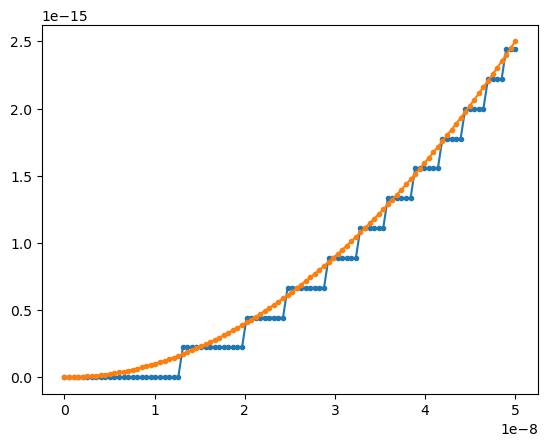

In [64]:
print("Ejercicio 4")

print(f"(raiz 2 al cuadrada) - 2 = {np.sqrt(2)**2-2}")

#valores x espaciados, 
import matplotlib.pyplot as plt

x = np.linspace(0,5e-8,100)

def fa(x): return np.sqrt(2*(x*x) +1) - 1

def fb(x): return (2*x*x)/(np.sqrt(2*(x*x) +1) + 1)

plt.plot(x, fa(x), 'o-', markersize=3, label="fa(x)")
plt.plot(x, fb(x), 'o-', markersize=3, label="fb(x)")



plt.show()
